In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 6.4 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:


dataset_url = 'https://www.kaggle.com/datasets/shuvokumarbasak4004/jackfruit-leaf-diseases'

od.download(dataset_url)



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mdsayemkabir
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shuvokumarbasak4004/jackfruit-leaf-diseases


100%|██████████| 286M/286M [00:04<00:00, 68.2MB/s]


In [3]:
!pip install patool  ## unzip rar files


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 3.5 MB/s eta 0:00:00


In [4]:
import os
from patoolib import extract_archive

def unzip_rar_files(folder_path):
    # Get a list of all files in the specified folder
    files = os.listdir(folder_path)

    # Iterate through each file in the folder
    for file in files:
        file_path = os.path.join(folder_path, file)

        # Check if the file is a .rar file
        if file.endswith(".rar"):
            try:
                # Extract the .rar file using patoolib
                extract_archive(file_path, outdir=folder_path)
                print(f"Successfully extracted: {file}")
            except Exception as e:
                print(f"Error extracting {file}: {e}")

# Specify the folder path containing the .rar files
folder_path = "/content/jackfruit-leaf-diseases/Jackfruit/train"

# Call the function to unzip .rar files in the specified folder
unzip_rar_files(folder_path)


In [5]:

base_dir = "/content/jackfruit-leaf-diseases/Jackfruit/train"

In [6]:
# prompt: count the number of images from every subfolders

import os

# Get the base directory
base_dir = "/content/jackfruit-leaf-diseases/Jackfruit/train"

# Get the list of subfolders
subfolders = os.listdir(base_dir)

# Initialize a dictionary to store the image counts
image_counts = {}

# Iterate through each subfolder
for subfolder in subfolders:
    # Get the path of the subfolder
    subfolder_path = os.path.join(base_dir, subfolder)

    # Check if the subfolder is a directory
    if os.path.isdir(subfolder_path):
        # Initialize the image count for the subfolder
        image_counts[subfolder] = 0

        # Get the list of files in the subfolder
        files = os.listdir(subfolder_path)

        # Iterate through each file in the subfolder
        for file in files:
            # Check if the file is an image
            if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
                # Increment the image count for the subfolder
                image_counts[subfolder] += 1

# Print the image counts for each subfolder
for subfolder, count in image_counts.items():
    print(f"Subfolder: {subfolder}, Image Count: {count}")


Subfolder: Healthy_Leaf_of_Jackfruit, Image Count: 2209
Subfolder: Algal_Leaf_Spot_of_Jackfruit, Image Count: 6221
Subfolder: Black_Spot_of_Jackfruit, Image Count: 4781


In [7]:
# prompt: check the image dimentions

import PIL

image_path = "/content/jackfruit-leaf-diseases/Jackfruit/train/Algal_Leaf_Spot_of_Jackfruit/IMG_20230308_142749_1.jpg"

# Open the image using PIL
image = PIL.Image.open(image_path)

# Get the image dimensions
width, height = image.size

# Print the image dimensions
print(f"Image dimensions: {width}x{height}")


Image dimensions: 256x256


In [9]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = "/content/jackfruit-leaf-diseases/Jackfruit/train"

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Healthy_Leaf_of_Jackfruit', 'Algal_Leaf_Spot_of_Jackfruit', 'Black_Spot_of_Jackfruit']


In [10]:
len(folders)

3

In [11]:
base_dir="/content/jackfruit-leaf-diseases/Jackfruit/train"

In [12]:
import os
import cv2
from tqdm import tqdm

def invert_colors(image):
    inverted_image = cv2.bitwise_not(image)
    return inverted_image

def invert_colors_in_subfolders(root_directory, output_directory):
    # Iterate through subfolders
    for subfolder in os.listdir(root_directory):
        subfolder_path = os.path.join(root_directory, subfolder)

        # Check if it's a directory
        if os.path.isdir(subfolder_path):
            # Define source and output directories for the current subfolder
            source_directory = subfolder_path
            output_subfolder = os.path.join(output_directory, subfolder)

            # Create output directory if it doesn't exist
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)

            # Process images in the current subfolder
            image_files = [f for f in os.listdir(source_directory) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]
            for file_name in tqdm(image_files, desc="Processing " + subfolder):
                # Construct the input and output paths
                input_image_path = os.path.join(source_directory, file_name)
                output_image_path = os.path.join(output_subfolder, file_name)

                # Read the image
                image = cv2.imread(input_image_path)

                # Check if the image is loaded successfully
                if image is not None:
                    # Perform color inversion
                    inverted_image = invert_colors(image)

                    # Save the inverted image
                    cv2.imwrite(output_image_path, inverted_image)
                else:
                    print("Error: Could not open or find the image:", input_image_path)

# Example usage
root_directory = '/content/jackfruit-leaf-diseases/Jackfruit/train'
output_directory = '/content/invert'  # Provide the path to your output directory
invert_colors_in_subfolders(root_directory, output_directory)


Processing Black_Spot_of_Jackfruit: 100%|██████████| 4781/4781 [00:11<00:00, 414.73it/s]


In [13]:
base_dir = "/content/invert"

In [14]:
import os
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

def augment_images(source_directory, output_directory, target_count=8000):
    # Create an ImageDataGenerator
    datagen = ImageDataGenerator(
    featurewise_center=True,
    samplewise_center=True,
    featurewise_std_normalization=True,
    samplewise_std_normalization=True,
    zca_whitening=True,
    zca_epsilon=1e-06,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=None,
    shear_range=0.2,
    zoom_range=0.1,
    channel_shift_range=0.2,
    fill_mode='nearest',
    cval=0.2,
    horizontal_flip=True,
    vertical_flip=True,
)

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc="Augmenting images"):
        img_path = os.path.join(source_directory, filename)
        img = image.load_img(img_path)
        img_array = image.img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)

        # Generate augmented images
        i = 0
        for batch in datagen.flow(img_array, batch_size=1, save_to_dir=output_directory, save_prefix='aug', save_format='jpg'):
            i += 1
            if i >= images_per_original:
                break

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    for i in range(len(output_images) - target_count):
        os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

import os

# Specify the root directory containing subfolders
root_directory = base_dir

# Iterate through subfolders
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)

    # Check if it's a directory
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented_invert', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=8000)

/usr/local/lib/python3.10/dist-packages/keras/src/preprocessing/image.py:1451: UserWarning: This ImageDataGenerator specifies `zca_whitening` which overrides setting of`featurewise_std_normalization`.
  warnings.warn(
Augmenting images:   0%|          | 0/2209 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/keras/src/preprocessing/image.py:1862: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/preprocessing/image.py:1885: UserWarning: This ImageDataGenerator specifies `zca_whitening`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
Augmenting images: 100%|██████████| 2209/2209 [01:51<00:00, 19.74it/s]


Augmentation complete. Total images in '/content/augmented_invert/Healthy_Leaf_of_Jackfruit': 4849


Augmenting images: 100%|██████████| 6221/6221 [01:45<00:00, 59.23it/s]


Augmentation complete. Total images in '/content/augmented_invert/Algal_Leaf_Spot_of_Jackfruit': 4593


Augmenting images: 100%|██████████| 4781/4781 [01:24<00:00, 56.39it/s]

Augmentation complete. Total images in '/content/augmented_invert/Black_Spot_of_Jackfruit': 3793


In [15]:
import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)

Streaming output truncated to the last 5000 lines.
Processing file: rotated_IMG_20230308_111020.jpg
Cleaned image saved at: /content/invert/Black_Spot_of_Jackfruit/rotated_IMG_20230308_111020.jpg
Processing file: rotated_IMG_20230308_113640_1.jpg
Cleaned image saved at: /content/invert/Black_Spot_of_Jackfruit/rotated_IMG_20230308_113640_1.jpg
Processing file: flipped_vertical_IMG_20230308_112129_1.jpg
Cleaned image saved at: /content/invert/Black_Spot_of_Jackfruit/flipped_vertical_IMG_20230308_112129_1.jpg
Processing file: brightened_IMG_20230308_113821.jpg
Cleaned image saved at: /content/invert/Black_Spot_of_Jackfruit/brightened_IMG_20230308_113821.jpg
Processing file: flipped_vertical_IMG_20230308_113408.jpg
Cleaned image saved at: /content/invert/Black_Spot_of_Jackfruit/flipped_vertical_IMG_20230308_113408.jpg
Processing file: pca_augmented_IMG_20230308_110620.jpg
Cleaned image saved at: /content/invert/Black_Spot_of_Jackfruit/pca_augmented_IMG_20230308_110620.jpg
Processing file: 

In [16]:
base_dir = '/content/augmented_invert'

In [17]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [18]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [19]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 9264 images belonging to 3 classes.
Found 1983 images belonging to 3 classes.
Found 1988 images belonging to 3 classes.


In [20]:
test_labels = np.array(test_generator.labels)

In [31]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50V2, NASNetMobile

def create_ResNet50V2_nasnetmobile_model(input_shape, num_classes):
    """
    Args:
      input_shape: tuple, shape of the input images (height, width, channels)
      num_classes: int, number of output classes

    Returns:
      A Keras model instance
    """
    ResNet50V2_backbone = ResNet50V2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    nasnet_backbone = NASNetMobile(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the DenseNet169 and NASNetMobile backbone layers
    ResNet50V2_backbone.trainable = False
    nasnet_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # DenseNet169 Backbone
    ResNet50V2_features = ResNet50V2_backbone(input_layer)
    ResNet50V2_features = GlobalAveragePooling2D()(ResNet50V2_features)

    # NASNetMobile Backbone
    nasnet_features = nasnet_backbone(input_layer)
    nasnet_features = GlobalAveragePooling2D()(nasnet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([ResNet50V2_features, nasnet_features])
    x = layers.Flatten()(combined_features)
    #x = layers.BatchNormalization()(x)
    # Dense layer with Batch Normalization
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model



In [35]:
input_shape = (224, 224, 3)  # Input image shape
num_classes = 3  # Number of output classes


model = create_ResNet50V2_nasnetmobile_model(input_shape, num_classes)

optim = keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.004,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=True,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adamw"
)

model.compile(
    optimizer=optim,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/25
145/145 [==============================] - 182s 1s/step - loss: 0.2817 - accuracy: 0.8900 - val_loss: 0.1925 - val_accuracy: 0.9228 - lr: 0.0010
Epoch 2/25
145/145 [==============================] - 143s 989ms/step - loss: 0.1544 - accuracy: 0.9398 - val_loss: 0.1343 - val_accuracy: 0.9511 - lr: 0.0010
Epoch 3/25
145/145 [==============================] - 144s 989ms/step - loss: 0.1300 - accuracy: 0.9523 - val_loss: 0.0986 - val_accuracy: 0.9647 - lr: 0.0010
Epoch 4/25
145/145 [==============================] - 144s 991ms/step - loss: 0.1038 - accuracy: 0.9606 - val_loss: 0.0637 - val_accuracy: 0.9753 - lr: 0.0010
Epoch 5/25
145/145 [==============================] - 143s 985ms/step - loss: 0.0962 - accuracy: 0.9637 - val_loss: 0.0780 - val_accuracy: 0.9718 - lr: 0.0010
Epoch 6/25
145/145 [==============================] - 144s 991ms/step - loss: 0.0908 - accuracy: 0.9644 - val_loss: 0.0615 - val_accuracy: 0.9768 - lr: 0.0010
Epoch 7/25
145/145 [=============================

<Figure size 640x480 with 0 Axes>

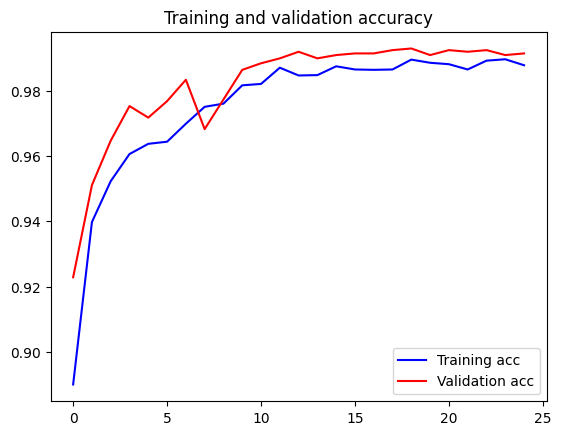

<Figure size 640x480 with 0 Axes>

In [39]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

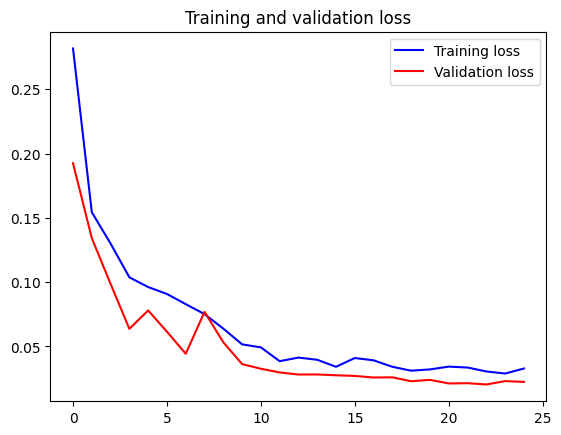

In [40]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

32/32 [==============================] - 22s 325ms/step


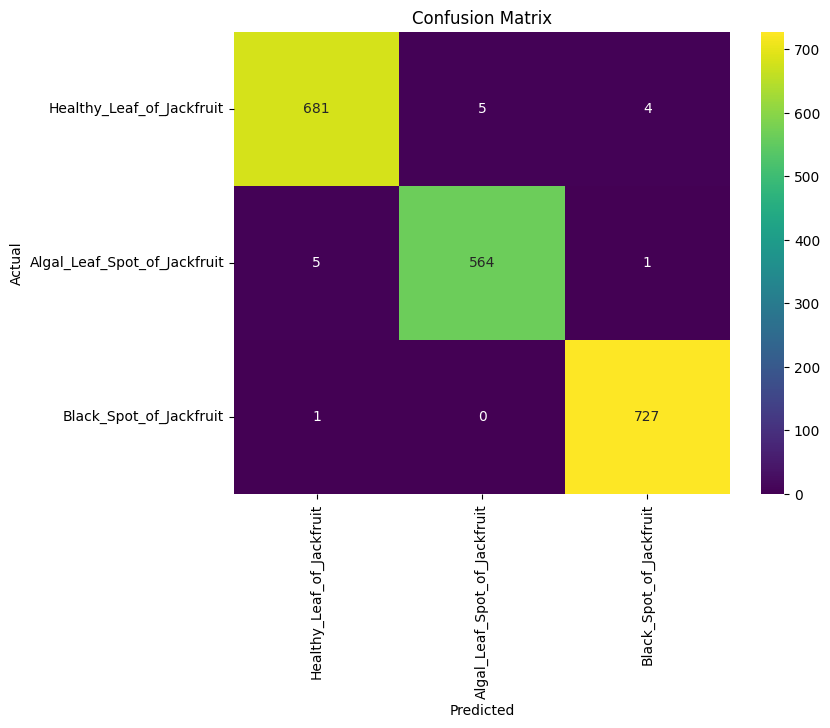

Precision: 0.9912126537785588
Recall: 0.9912126537785588
F1 Score: 0.9912126537785588


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

32/32 [==============================] - 9s 283ms/step


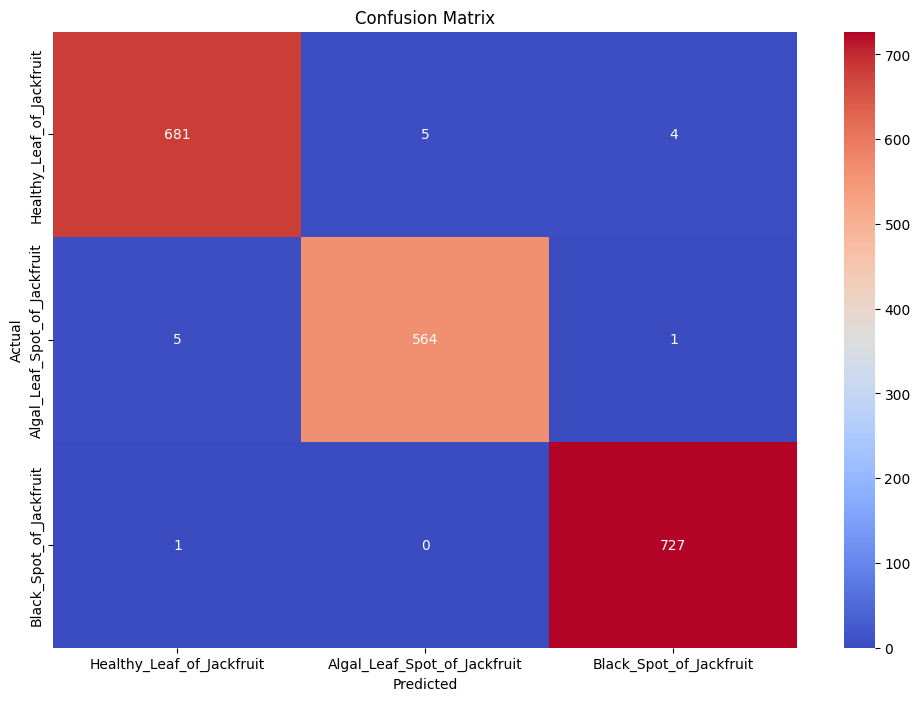

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



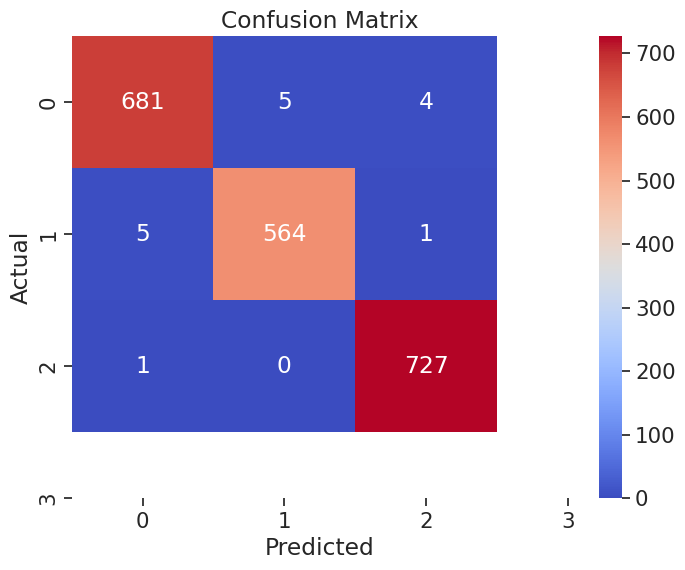

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


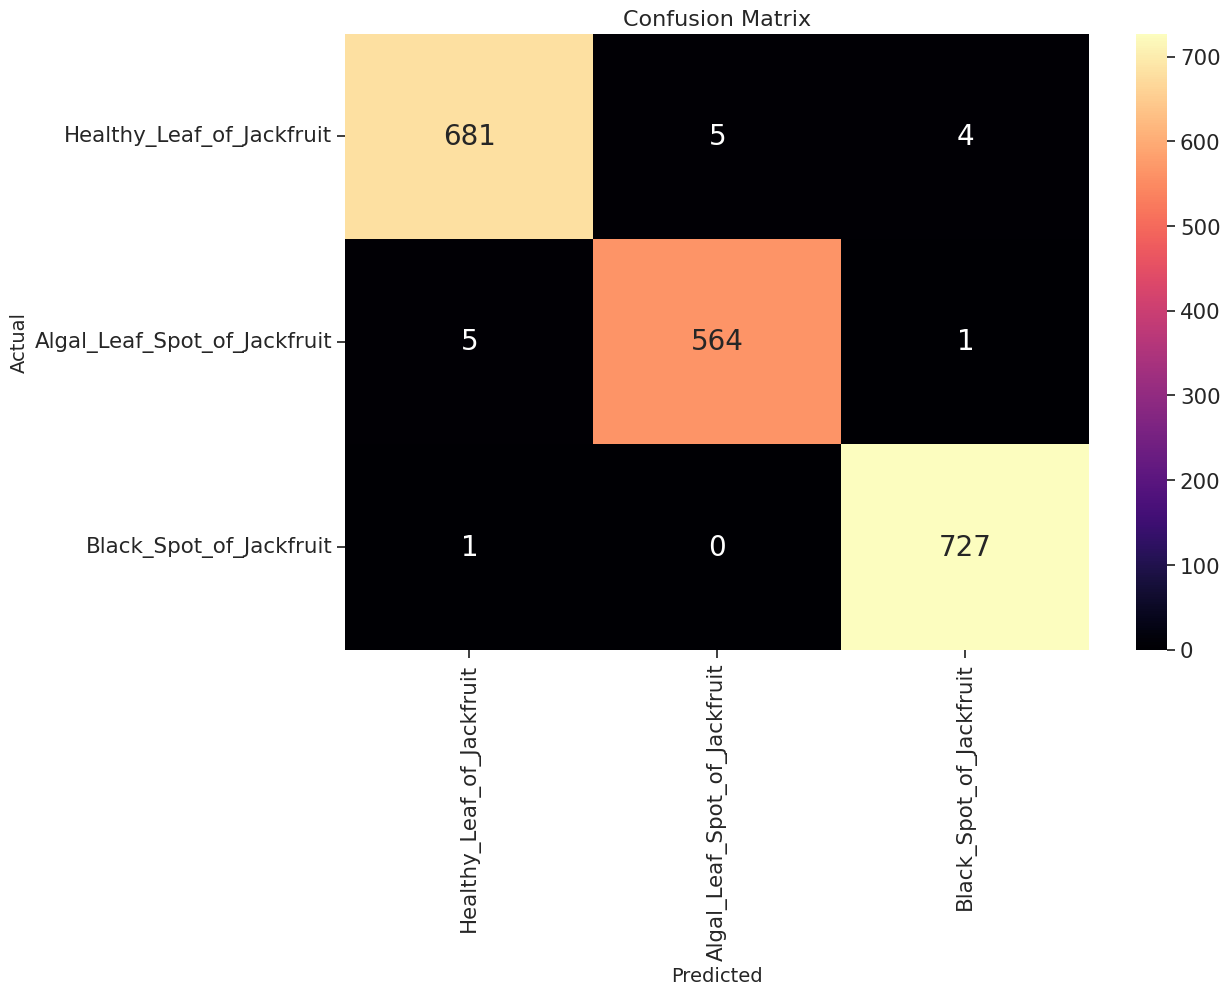

In [44]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [45]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

In [46]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       690
           1       0.99      0.99      0.99       570
           2       0.99      1.00      1.00       728

    accuracy                           0.99      1988
   macro avg       0.99      0.99      0.99      1988
weighted avg       0.99      0.99      0.99      1988



In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming test_labels and predicted_labels are your actual and predicted labels
precision = precision_score(test_labels, predicted_labels, average='weighted')
recall = recall_score(test_labels, predicted_labels, average='weighted')
f1 = f1_score(test_labels, predicted_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.9919478542177002
Recall: 0.9919517102615694
F1 Score: 0.9919451964344118


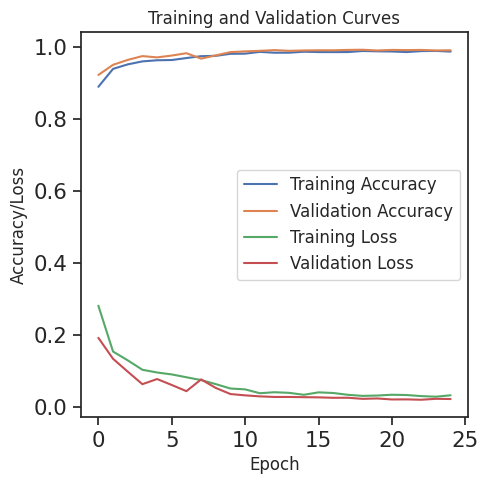

In [48]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


<Figure size 640x480 with 0 Axes>

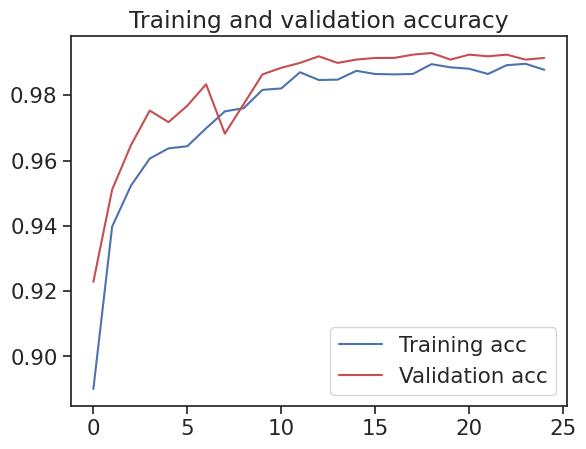

<Figure size 640x480 with 0 Axes>

In [49]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

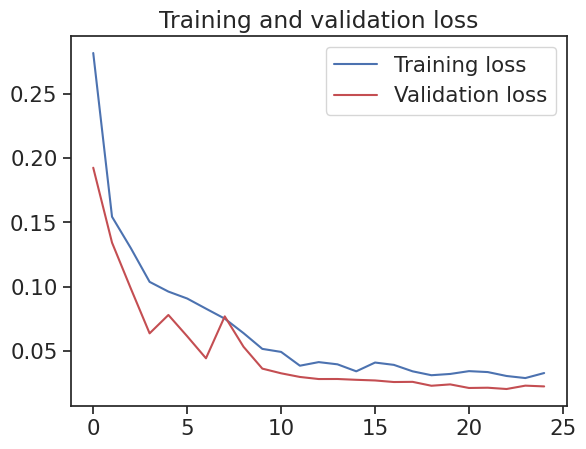

In [50]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [51]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


32/32 [==============================] - 10s 315ms/step
                              precision    recall  f1-score   support

   Healthy_Leaf_of_Jackfruit       0.99      0.99      0.99       690
Algal_Leaf_Spot_of_Jackfruit       0.99      0.99      0.99       570
     Black_Spot_of_Jackfruit       0.99      1.00      1.00       728

                    accuracy                           0.99      1988
                   macro avg       0.99      0.99      0.99      1988
                weighted avg       0.99      0.99      0.99      1988



In [52]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


32/32 [==============================] - 10s 319ms/step
Class Healthy_Leaf_of_Jackfruit:
Precision: 0.9913
Recall: 0.9870
F1-score: 0.9891

Class Algal_Leaf_Spot_of_Jackfruit:
Precision: 0.9912
Recall: 0.9895
F1-score: 0.9903

Class Black_Spot_of_Jackfruit:
Precision: 0.9932
Recall: 0.9986
F1-score: 0.9959



31/31 [==============================] - 9s 282ms/step


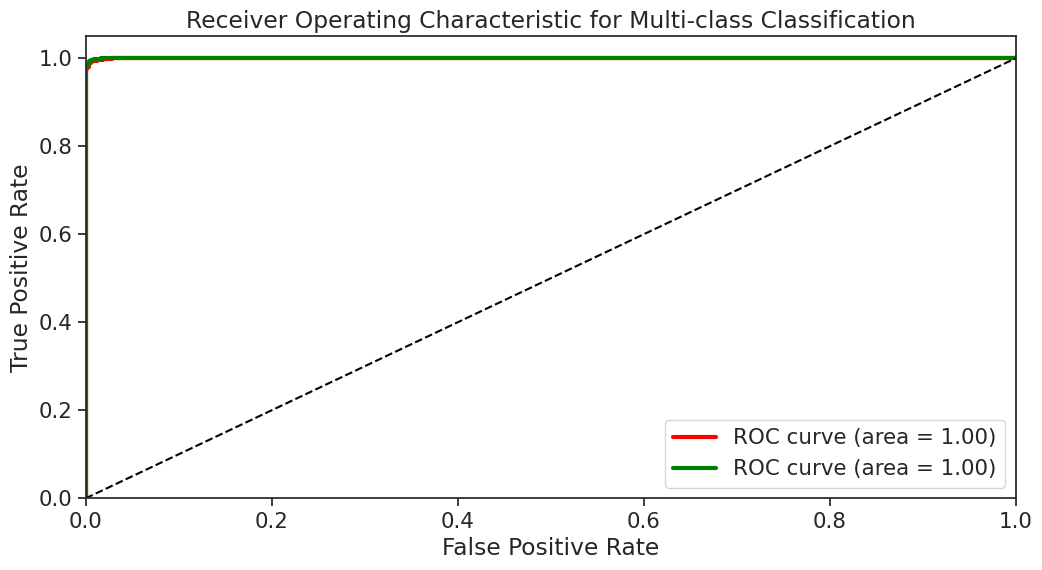

AUC scores:
Class 1: 0.9997968483433599
Class 2: 0.9999004628477579


In [53]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 2  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


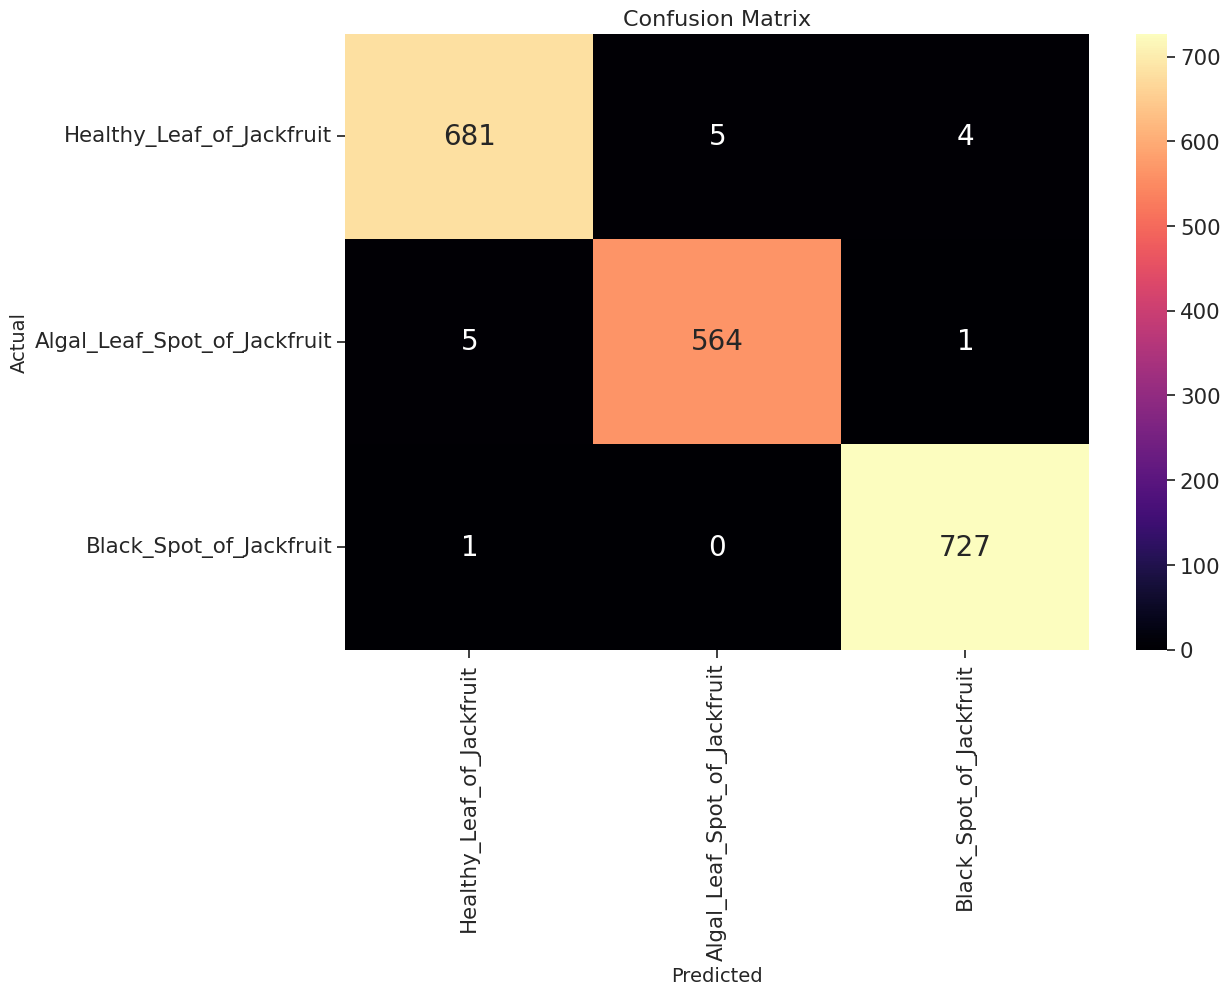

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


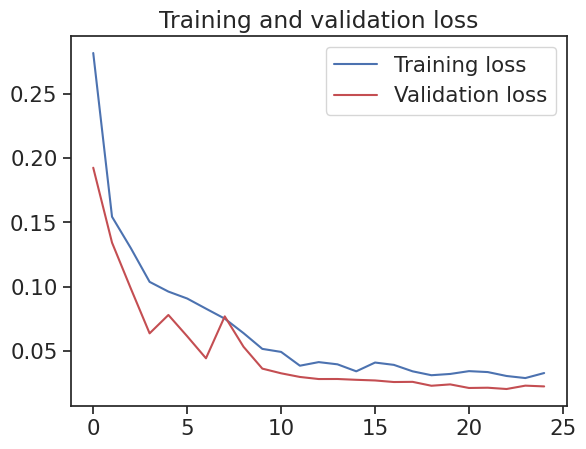

In [55]:

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

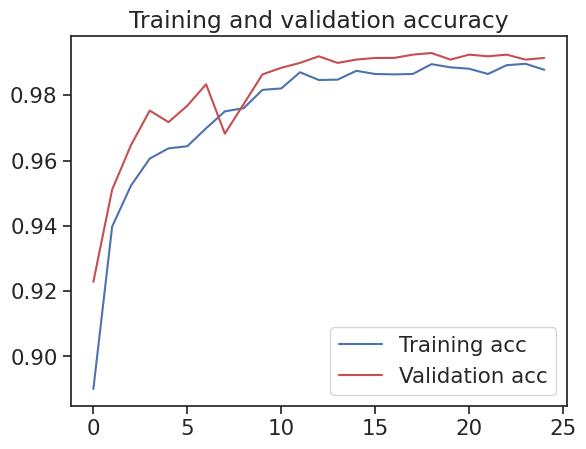

<Figure size 640x480 with 0 Axes>

In [56]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

In [57]:
model.save('jackfruit.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


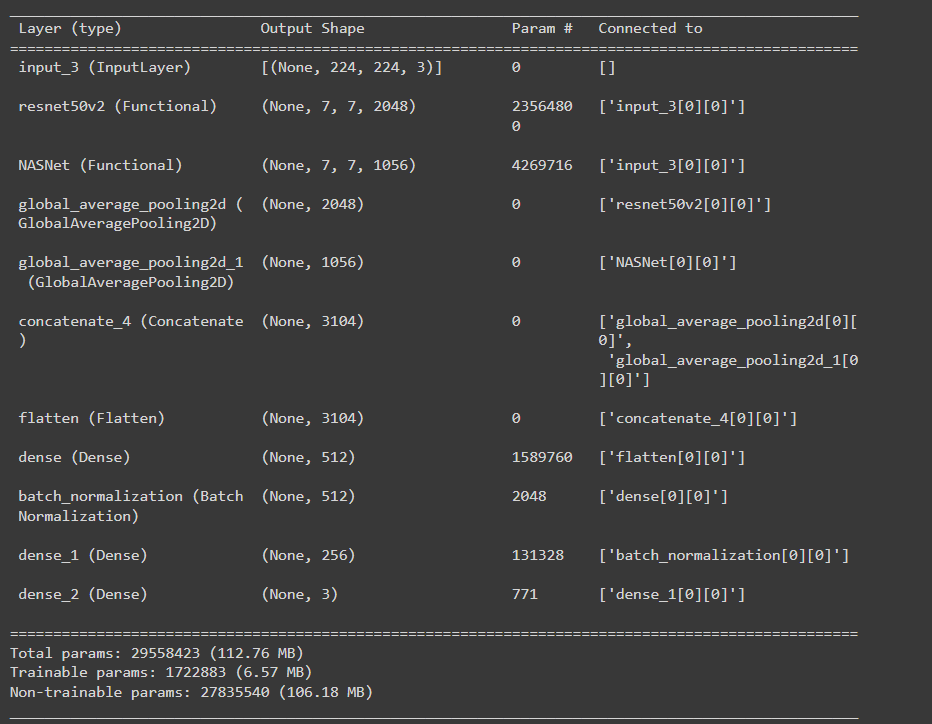